# Task 4: Drug Synergy Prediction

This notebook demonstrates **Task 4** of the scGVP downstream analysis pipeline: predicting whether two drugs, when applied together, will produce a synergistic, antagonistic, or additive transcriptomic response.

## Rationale
Drug combination therapy is a key strategy in oncology and infectious disease. The scGVP model represents each drug's perturbation as a shift in latent space. By composing two drug contexts and comparing the predicted combined response to the expected additive response (Bliss independence model), we obtain a synergy score for each drug pair.

## Bliss Independence Model
$$\text{Synergy Score} = O - E$$
where:
- $O$ = observed (predicted) combination effect
- $E = d_1 + d_2 - d_1 \cdot d_2$ = expected effect under independence

**Score > 0.1** → Synergy | **Score < −0.1** → Antagonism | Otherwise → Additive

## Workflow
1. Load model and LINCS dataset
2. Process reference dataset
3. Extract drug latent-space contexts
4. Screen all pairwise drug combinations
5. Rank combinations by synergy score
6. Visualise the synergy landscape

## Outputs
- `synergy_results.csv` — full ranked combination table
- `synergy_landscape.png` — horizontal bar chart of top synergistic/antagonistic pairs

## 1. Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

from model import GINVAE
from dataset import ChunkedGeneGraphDataset
from task4 import DrugSynergyPrediction

print(f"PyTorch: {torch.__version__}")
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.9.0.dev20250827+cu129
Device : cuda


## 2. Configuration

Datasets and model weights are available at:  
**https://huggingface.co/datasets/Mike2481/Dataset4scGVP/tree/main**

In [2]:
MODEL_PATH  = '../src/best_gin_vae_model_node_level.pth'
LINCS_PATH  = '../lincs/merged_all_965_with_morgan.h5ad'
TAHOE_PATHS = [f'../minitahoe/p{i}_with_morgan.h5ad' for i in range(1, 15)]
REF_CACHE   = './output/reference_latents.pkl'
SAVE_DIR    = './output/task2_drug_network'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('./output', exist_ok=True)

# Number of drug combinations to screen
N_COMBINATIONS = 30

## 3. Load Model

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GINVAE(input_dim=1, hidden_dim=300, latent_dim=100, num_layers=2).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"Model loaded on {device}")

Model loaded on cuda


## 4. Load Data

In [4]:
lincs_adata = sc.read_h5ad(LINCS_PATH)
print(f"LINCS dataset: {lincs_adata.shape[0]} cells × {lincs_adata.shape[1]} genes")
print(f"Unique drugs : {lincs_adata.obs['canonical_smiles'].nunique()}")

lincs_dataset = ChunkedGeneGraphDataset([LINCS_PATH], split='test')
print(f"Dataset samples: {len(lincs_dataset)}")

LINCS dataset: 157138 cells × 965 genes
Unique drugs : 8316
Found 32 chunks with 157138 total samples
Dataset samples: 157138


## 5. Process Reference Dataset

The synergy prediction relies on the model's cached reference latents to extract per-drug latent contexts.

In [5]:
model.process_reference_dataset(
    x_ref_dataset=lincs_dataset,
    save_path=REF_CACHE,
    force_reprocess=False
)
print("Reference dataset ready.")

Loading existing processed data from ./output/reference_latents.pkl
Loaded reference data metadata from ./output/reference_latents.pkl
Total samples available: 157138
Loading data from chunks...


Loading chunks: 100%|██████████| 16/16 [00:00<00:00, 16.11it/s, file=chunk_15.pkl]


Loaded and filtered 157138 samples from chunks
Computing biological context from 78569 control and 78569 perturb samples
Extracting graph-level latent representations...


Processing perturb samples: 100%|██████████| 78569/78569 [00:01<00:00, 64990.25it/s]


Computing mean representations...
References computed successfully.
Control ref shape: torch.Size([1, 100]), norm: 3.5154
perturb ref shape: torch.Size([1, 100]), norm: 3.5215
Biological context norm: 0.0068
Reference dataset ready.


## 6. Initialise DrugSynergyPrediction

In [6]:
task4 = DrugSynergyPrediction(model, device)
print("DrugSynergyPrediction initialised.")

DrugSynergyPrediction initialised.


## 7. Screen Drug Combinations

For each pair, the model:
1. Encodes a control sample to latent space
2. Applies Drug 1's latent context → decodes Drug 1 response
3. Applies Drug 2's latent context → decodes Drug 2 response
4. Applies both contexts simultaneously → decodes combo response
5. Computes Bliss synergy score

In [7]:
synergy_results = task4.screen_drug_combinations(
    adata=lincs_adata,
    test_dataset=lincs_dataset,
    n_combinations=N_COMBINATIONS
)

# Save to CSV
synergy_results.to_csv(os.path.join(SAVE_DIR, 'synergy_results.csv'), index=False)

print(f"\nScreened {len(synergy_results)} drug combinations")
print(f"  Synergistic  : {(synergy_results['effect_type'] == 'Synergy').sum()}")
print(f"  Antagonistic : {(synergy_results['effect_type'] == 'Antagonism').sum()}")
print(f"  Additive     : {(synergy_results['effect_type'] == 'Additive').sum()}")

Screening drug combinations for synergy...
Extracting drug contexts...


Processing drugs: 100%|██████████| 20/20 [00:11<00:00,  1.80it/s]


Extracted contexts for 20 drugs


Evaluating combinations: 100%|██████████| 30/30 [00:02<00:00, 11.13it/s]


Screened 30 drug combinations
  Synergistic  : 30
  Antagonistic : 0
  Additive     : 0


In [8]:
print("\nTop 10 combinations by synergy score:")
display(synergy_results.head(10)[['drug1', 'drug2', 'synergy_score', 'effect_type']])


Top 10 combinations by synergy score:


,drug1,drug2,synergy_score,effect_type
8,Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=CCC53,Brc1ccccc1OCC(=O)NCCc2nc3ccccc3[nH]2,0.291629,Synergy
27,C(C=Cc1ccccc1)N1CCN(CC1)C(c1ccccc1)c1ccccc1,C(Nc1nc(NCc2ccccc2)c2ccccc2n1)c1ccccc1,0.291624,Synergy
12,C(CN1CCOCC1)Sc2nc3ccccc3n2Cc4ccccc4,C(N(Cc1ccccc1)Cc2ccccc2)c3nnc(s3)c4cc5ccccc5[nH]4,0.291456,Synergy
21,BrCC(=O)NCCc1ccc2ccccc2c1,C(Nc1nc(NCc2ccccc2)c2ccccc2n1)c1ccccc1,0.291419,Synergy
25,C(N(Cc1ccccc1)c1ccccc1)C1=NCCN1,C(N1CCN(CC1)c1ncccn1)c1ccc2OCOc2c1,0.291389,Synergy
3,Brc1ccc(cc1)-c1csc(n1)N1CCNCC1,Brc1ccccc1CNC(=O)c1cccs1,0.291365,Synergy
9,Brc1ccc(cc1)-c1csc(n1)N1CCNCC1,Brc1ccccc1OCC(=O)NCCc2nc3ccccc3[nH]2,0.291328,Synergy
28,C(N(Cc1ccccc1)c1ccccc1)C1=NCCN1,C(Nc1ncnc2ccc(cc12)c3ccc4OCOc4c3)c5cccnc5,0.291297,Synergy
26,Brc1ccccc1OCC(=O)NCCc2nc3ccccc3[nH]2,C(CN1CCOCC1)Sc2nc3ccccc3n2Cc4ccccc4,0.291234,Synergy
16,Brc1cccc(Nc2ncnc3ccc(NC(=O)C=C)cc23)c1,Brc1ccccc1CNC(=O)c1cccs1,0.291225,Synergy


## 8. Synergy Score Distribution

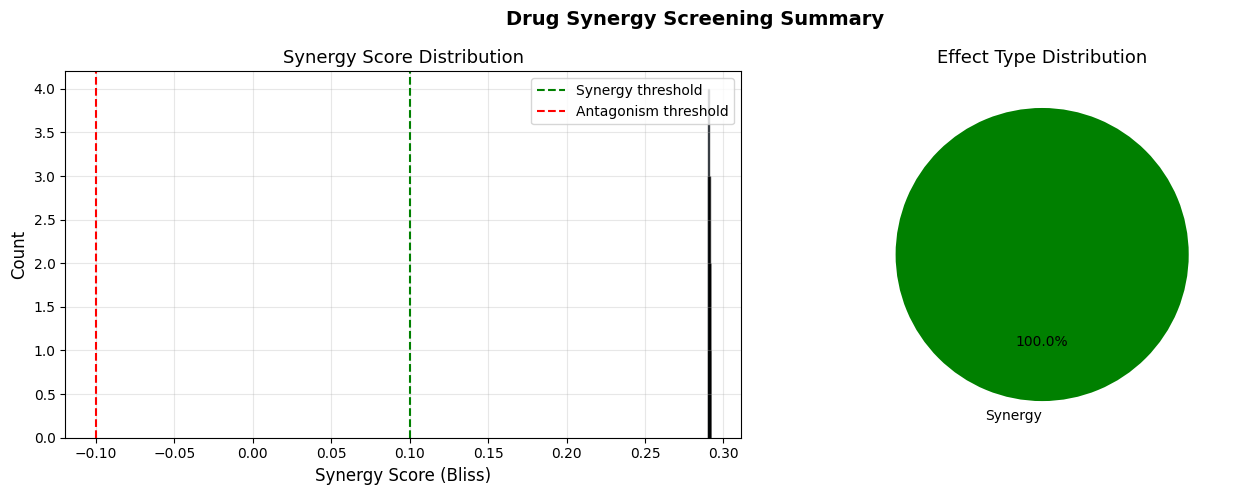

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of synergy scores
colors = synergy_results['effect_type'].map({'Synergy': 'green', 'Antagonism': 'red', 'Additive': 'gray'})
axes[0].hist(synergy_results['synergy_score'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0.1,  color='green', linestyle='--', linewidth=1.5, label='Synergy threshold')
axes[0].axvline(-0.1, color='red',   linestyle='--', linewidth=1.5, label='Antagonism threshold')
axes[0].set_xlabel('Synergy Score (Bliss)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Synergy Score Distribution', fontsize=13)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Effect type pie chart
type_counts = synergy_results['effect_type'].value_counts()
axes[1].pie(
    type_counts.values,
    labels=type_counts.index,
    colors=['green', 'gray', 'red'][:len(type_counts)],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Effect Type Distribution', fontsize=13)

plt.suptitle('Drug Synergy Screening Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'synergy_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Synergy Landscape Visualisation

A horizontal bar chart showing the most synergistic and antagonistic drug combinations. Green bars indicate synergy; red bars indicate antagonism.

In [10]:
landscape_path = os.path.join(SAVE_DIR, 'synergy_landscape.png')
task4.visualize_synergy_landscape(synergy_results, top_k=20, save_path=landscape_path)
print(f"Synergy landscape saved to: {landscape_path}")

Synergy landscape saved to ./output/task2_drug_network/synergy_landscape.png
Synergy landscape saved to: ./output/task2_drug_network/synergy_landscape.png


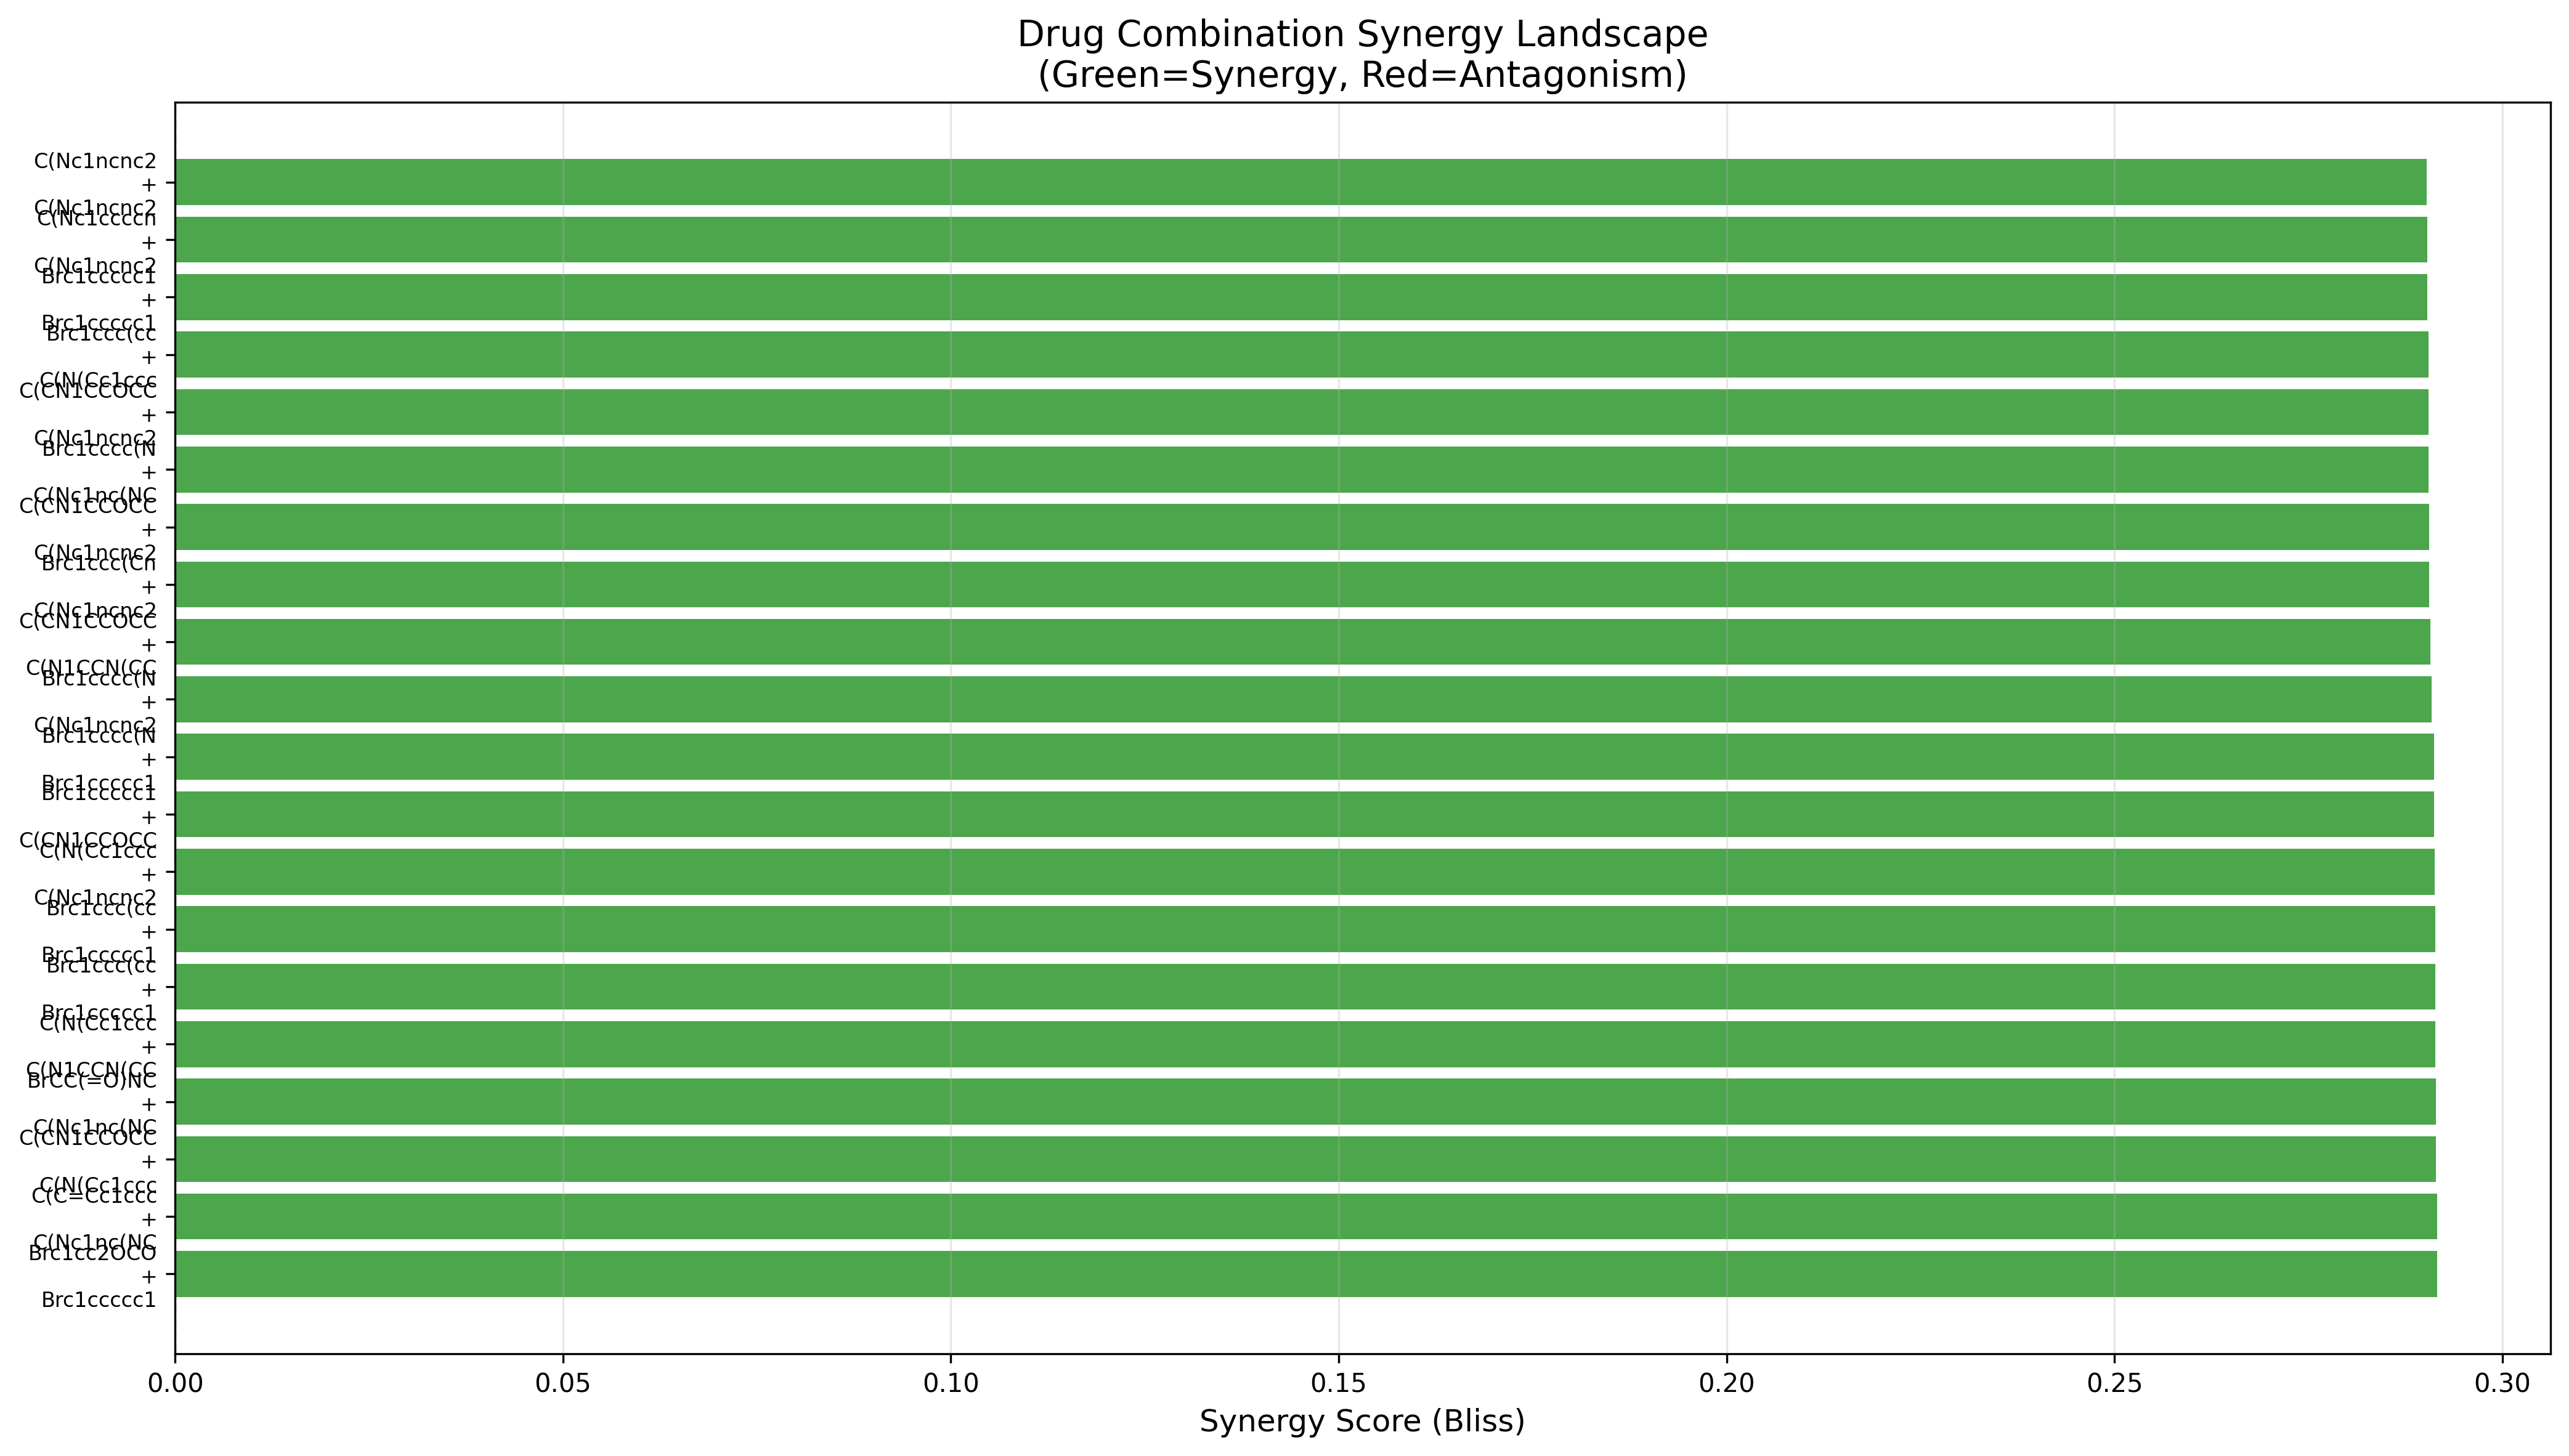

In [11]:
# Display the saved figure
from IPython.display import Image
Image(landscape_path)

## 10. Deep-Dive: Single Drug Pair Analysis

For the top synergistic pair, we visualise the individual drug effects, additive expectation, and the predicted combination response.

In [12]:
from torch_geometric.data import DataLoader as PyGDataLoader

if len(synergy_results) > 0:
    top_row = synergy_results.iloc[0]
    drug1_smiles = top_row['drug1']
    drug2_smiles = top_row['drug2']
    synergy_score = top_row['synergy_score']

    print(f"Top pair: Drug1={drug1_smiles[:30]}... | Drug2={drug2_smiles[:30]}...")
    print(f"Synergy score: {synergy_score:.4f} ({top_row['effect_type']})")
else:
    print("No results available.")

Top pair: Drug1=Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=... | Drug2=Brc1ccccc1OCC(=O)NCCc2nc3ccccc...
Synergy score: 0.2916 (Synergy)


## 11. Summary Statistics

In [13]:
print("=" * 60)
print("Task 4: Drug Synergy Prediction — Summary")
print("=" * 60)
print(f"  Combinations screened    : {len(synergy_results)}")
print(f"  Synergistic pairs        : {(synergy_results['effect_type'] == 'Synergy').sum()}")
print(f"  Antagonistic pairs       : {(synergy_results['effect_type'] == 'Antagonism').sum()}")
print(f"  Additive pairs           : {(synergy_results['effect_type'] == 'Additive').sum()}")
print(f"  Score range              : [{synergy_results['synergy_score'].min():.4f}, {synergy_results['synergy_score'].max():.4f}]")
print(f"  Mean score               : {synergy_results['synergy_score'].mean():.4f}")
if len(synergy_results) > 0:
    best = synergy_results.iloc[0]
    print(f"  Best synergistic pair    : {best['drug1'][:20]} + {best['drug2'][:20]}")
    print(f"  Best synergy score       : {best['synergy_score']:.4f}")
print(f"\nAll outputs saved to: {SAVE_DIR}")

Task 4: Drug Synergy Prediction — Summary
  Combinations screened    : 30
  Synergistic pairs        : 30
  Antagonistic pairs       : 0
  Additive pairs           : 0
  Score range              : [0.2903, 0.2916]
  Mean score               : 0.2910
  Best synergistic pair    : Brc1cc2OCOc2cc1C3Nc4 + Brc1ccccc1OCC(=O)NCC
  Best synergy score       : 0.2916

All outputs saved to: ./output/task2_drug_network
